# Ejercicio 10: solución paramétrica de la ecuación de Lyapunov

*(Traducción a Python de `ejercicio10.m`, usando `sympy`)*

Buscamos la solución general $P$ (aquí llamada $L$) de la ecuación de Lyapunov $A^TP+PA=-I$ para una matriz $A$ en forma companera $2\times2$, en función de sus coeficientes simbólicos $a,b$:

$$A = \begin{pmatrix}0&1\\-b&-a\end{pmatrix}$$

In [1]:
import sympy as sp
sp.init_printing()

In [2]:
L11, L12, L22, a, b = sp.symbols('L11 L12 L22 a b', real=True)

A = sp.Matrix([[0, 1], [-b, -a]])
A

⎡0   1 ⎤
⎢      ⎥
⎣-b  -a⎦

Definimos $L$ (nuestra $P$) como una matriz simétrica genérica $2\times2$, con tres incógnitas: $L_{11}, L_{12}, L_{22}$.

In [3]:
L = sp.Matrix([[L11, L12], [L12, L22]])
L

⎡L₁₁  L₁₂⎤
⎢        ⎥
⎣L₁₂  L₂₂⎦

Formamos la expresión de la ecuación de Lyapunov (sin el signo, para trabajar con ella como expresión libre):

In [4]:
liapu = L*A + A.T*L
liapu

⎡     -2⋅L₁₂⋅b        L₁₁ - L₁₂⋅a - L₂₂⋅b⎤
⎢                                        ⎥
⎣L₁₁ - L₁₂⋅a - L₂₂⋅b    2⋅L₁₂ - 2⋅L₂₂⋅a  ⎦

Igualando cada entrada de `liapu` a $-I=\begin{pmatrix}-1&0\\0&-1\end{pmatrix}$ (tres ecuaciones, ya que la matriz es simétrica), obtenemos un sistema lineal $3\times3$ en $L_{11}, L_{12}, L_{22}$ — el `.m` original ya trae este sistema resuelto a mano en forma de matriz de coeficientes.

In [5]:
coef = sp.Matrix([
    [0,   -2*b,  0],
    [1,   -a,   -b],
    [0,    2,   -2*a]
])
ind = sp.Matrix([-1, 0, -1])

Resolvemos el sistema lineal. `\` (mldivide) de MATLAB se traduce como el método `.solve(...)` de `sympy.Matrix` para sistemas simbólicos exactos (para sistemas puramente numéricos, la alternativa habitual en Python sería `np.linalg.solve(coef, ind)`, pero aquí `a` y `b` son símbolos, así que necesitamos la versión simbólica).

In [6]:
inco = coef.solve(ind)
inco

⎡ 2    2    ⎤
⎢a  + b  + b⎥
⎢───────────⎥
⎢   2⋅a⋅b   ⎥
⎢           ⎥
⎢     1     ⎥
⎢    ───    ⎥
⎢    2⋅b    ⎥
⎢           ⎥
⎢ 1      1  ⎥
⎢─── + ─────⎥
⎣2⋅a   2⋅a⋅b⎦

Reconstruimos $L$ con la solución encontrada,

In [7]:
L = sp.Matrix([
    [inco[0], inco[1]],
    [inco[1], inco[2]]
])
L

⎡ 2    2                 ⎤
⎢a  + b  + b       1     ⎥
⎢───────────      ───    ⎥
⎢   2⋅a⋅b         2⋅b    ⎥
⎢                        ⎥
⎢     1        1      1  ⎥
⎢    ───      ─── + ─────⎥
⎣    2⋅b      2⋅a   2⋅a⋅b⎦

Podemos comprobar que, efectivamente, esta $L$ satisface la ecuación de Lyapunov original,

In [8]:
comprobacion = sp.simplify(L*A + A.T*L)
comprobacion

⎡-1  0 ⎤
⎢      ⎥
⎣0   -1⎦

Y por último, sus autovalores, traza y determinante,

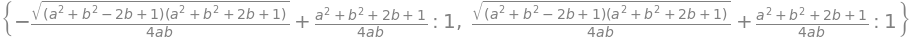

In [9]:
auto = L.eigenvals()
auto

In [10]:
traza = sp.simplify(L.trace())
traza

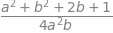

In [11]:
dl = sp.simplify(L.det())
dl

Dado que $a>0$ y $b>0$ (condiciones de estabilidad de $A$, que es Hurwitz cuando $s^2+as+b$ tiene ambas raíces con parte real negativa), tanto la traza como el determinante de $L$ son positivos, lo que confirma que $L\succ0$: la solución de la ecuación de Lyapunov es efectivamente definida positiva, tal y como debe ser cuando $A$ es Hurwitz.